In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub mlflow xgboost -q
!pip install dagshub
!pip install mlflow
import xgboost as xgb
import mlflow
import mlflow.xgboost
import dagshub
import warnings
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel

dagshub.init(repo_owner='akave23', repo_name='IEEE-CIS-Fraud-Detection-ML2', mlflow=True)
mlflow.set_experiment('ADABoost_Training_v1')

print(f'XGBoost version : {xgb.__version__}')
print(f'MLflow URI      : {mlflow.get_tracking_uri()}')

Accessing as akave23

Initialized MLflow to track repo "akave23/IEEE-CIS-Fraud-Detection-ML2"

Repository akave23/IEEE-CIS-Fraud-Detection-ML2 initialized!

XGBoost version : 3.2.0
MLflow URI      : https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow


In [3]:
train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv').merge(
    pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'),
    on='TransactionID', how='left')

y = train['isFraud'].values
X = train.drop(['isFraud', 'TransactionID'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train : {X_train.shape} | y_train : {y_train.shape} | fraud: {y_train.mean():.2%}')
print(f'X_valid : {X_valid.shape} | y_valid : {y_valid.shape} | fraud: {y_valid.mean():.2%}')

cat_cols  = X_train.select_dtypes(include='object').columns.tolist()
num_cols  = X_train.select_dtypes(include=np.number).columns.tolist()
print(f'Categorical cols: {len(cat_cols)} | Numeric cols: {len(num_cols)}')

X_train : (472432, 432) | y_train : (472432,) | fraud: 3.50%
X_valid : (118108, 432) | y_valid : (118108,) | fraud: 3.50%
Categorical cols: 31 | Numeric cols: 401


## **DATA CLEANING**

In [ ]:
from sklearn.impute import SimpleImputer

with mlflow.start_run(run_name='ADABoost_Cleaning'):
#remove high NaN columns(>90%)
    X_tr  = X_train.reset_index(drop=True).copy()
    X_val = X_valid.reset_index(drop=True).copy()
    
    nan_pct       = X_tr.isnull().mean()          
    high_nan_cols = nan_pct[nan_pct > 0.90].index.tolist()
    
    X_tr.drop(columns=high_nan_cols, inplace=True)
    X_val.drop(columns=[c for c in high_nan_cols if c in X_val.columns], inplace=True)
    
    print(f'\nSTEP 1 | High-NaN removed (>90%, counted on X_tr): {len(high_nan_cols)}')
    
    #create new columns for each column which had any NaN values 
    missing_cols = [c for c in X_tr.columns if X_tr[c].isnull().any()]  
    
    for col in missing_cols:
        nan_flag = col + '_was_nan'
        X_tr[nan_flag]  = X_tr[col].isnull().astype(np.int8)
        X_val[nan_flag] = X_val[col].isnull().astype(np.int8) if col in X_val.columns else 0
    

    print(f'STEP 2 | Missing indicators added: {len(missing_cols)}')
    
    #categorical columns
    cat_cols  = X_tr.select_dtypes(include='object').columns.tolist()
    high_card = [c for c in cat_cols if X_tr[c].nunique() > 50]
    low_card  = [c for c in cat_cols if X_tr[c].nunique() <= 50]
    
    # Frequency Encoding
    freq_maps = {}
    for col in high_card:
        freq_maps[col] = X_tr[col].value_counts(normalize=True).to_dict()  # ← X_tr-ზე!
        for df in [X_tr, X_val]:
            df[col] = df[col].map(freq_maps[col]).fillna(0.0)
    
    # Label Encoding
    label_encoders = {}
    for col in low_card:
        le = LabelEncoder()
        vocab = pd.concat([X_tr[col], X_val[col]], axis=0).astype(str)
        le.fit(vocab)
        label_encoders[col] = le
        for df in [X_tr, X_val]:
            df[col] = le.transform(df[col].astype(str))
    
    print(f'STEP 3 | Freq encoded: {len(high_card)} | Label encoded: {len(low_card)}')
    

    # median imputation
    nan_counts_before = {
        col: int(X_tr[col].isnull().sum())
        for col in missing_cols if col in X_tr.columns
    }
    
    imputer   = SimpleImputer(strategy='median')
    col_names = X_tr.columns.tolist()
    
    X_tr_arr   = imputer.fit_transform(X_tr)    
    X_val_arr  = imputer.transform(X_val)      
    
    X_tr   = pd.DataFrame(X_tr_arr,   columns=col_names)
    X_val  = pd.DataFrame(X_val_arr,  columns=col_names)
    
    print(f'STEP 4 | Median Imputation (fit on X_tr only)')
    print(f'  NaN in X_tr  after: {X_tr.isnull().sum().sum()}')
    print(f'  NaN in X_val after: {X_val.isnull().sum().sum()}')
    
    
    #outlier clipping
    skip_cap  = [c for c in X_tr.columns if c.endswith('_was_nan') or c == 'TransactionDT']
    cap_cols  = [c for c in X_tr.select_dtypes(include=np.number).columns if c not in skip_cap]
    
    cap_bounds   = {}
    capped_cols  = []
    capped_pcts  = []
    
    for col in cap_cols:
        lo = X_tr[col].quantile(0.01)  
        hi = X_tr[col].quantile(0.99)  
        n_out = int(((X_tr[col] < lo) | (X_tr[col] > hi)).sum())
        if n_out > 0:
            cap_bounds[col] = (lo, hi)
            capped_cols.append(col)
            capped_pcts.append(n_out / len(X_tr) * 100)
            for df in [X_tr, X_val]:
                df[col] = df[col].clip(lo, hi)   
    
    print(f'STEP 5 | Outlier capping (fit on X_tr): {len(capped_cols)} cols')
    

    corr_matrix = X_tr.select_dtypes(include=np.number).corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr   = [c for c in upper.columns if any(upper[c] > 0.95)]
    
    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in high_corr if c in df.columns], inplace=True)
    
        print(f'STEP 6 | High-corr removed (>0.95): {len(high_corr)}')


    variances = X_tr.var()                       
    low_var_cols = variances[variances < 0.01].index.tolist()
    
    for df in [X_tr, X_val]:
        df.drop(columns=[c for c in low_var_cols if c in df.columns], inplace=True)
    
    print(f'STEP 7 | Low-variance removed : {len(low_var_cols)}')
    

    n_high_nan   = len(high_nan_cols)
    n_low_var    = len(low_var_cols)
    n_indicators = len(missing_cols)
    n_final      = X_tr.shape[1]

mlflow.log_param('val_size', 0.20)
mlflow.log_param('split_stratified', True)
mlflow.log_param('nan_threshold', 0.90)
mlflow.log_param('imputation', 'median')
mlflow.log_param('outlier_cap', '1pct-99pct')
mlflow.log_param('corr_threshold', 0.95)
mlflow.log_param('high_card_encoding', 'frequency')
mlflow.log_param('low_card_encoding', 'label')

mlflow.log_metric('train_size',   len(X_tr))
mlflow.log_metric('val_size_rows',  len(X_val))

mlflow.log_metric('removed_high_nan', n_high_nan)
mlflow.log_metric('added_nan_indicators', n_indicators)
mlflow.log_metric('removed_low_var',  n_low_var)
mlflow.log_metric('capped_columns',   len(capped_cols))
mlflow.log_metric('final_n_features', n_final)



STEP 1 | High-NaN removed (>90%, counted on X_tr): 12
STEP 2 | Missing indicators added: 402
STEP 3 | Freq encoded: 6 | Label encoded: 23
STEP 4 | Median Imputation (fit on X_tr only)
  NaN in X_tr  after: 0
  NaN in X_val after: 0
STEP 5 | Outlier capping (fit on X_tr): 393 cols
STEP 6 | High-corr removed (>0.95): 463
STEP 6 | High-corr removed (>0.95): 463
STEP 7 | Low-variance removed : 58
🏃 View run ADABoost_Cleaning at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/3/runs/2d366869ee914942a5627e811824d0b2
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/3


## **FEATURE ENGINEERING**

In [ ]:
def compute_woe_iv(df_col, y, col_name, min_samples=50):
    df_tmp = pd.DataFrame({
        "cat": df_col.astype(str).fillna("missing"),
        "target": y
    })

    total_events = max(df_tmp["target"].sum(), 1)
    total_non_events = max((1 - df_tmp["target"]).sum(), 1)

    stats = df_tmp.groupby("cat")["target"].agg(["sum", "count"]).reset_index()
    stats.columns = ["cat", "events", "total"]

    stats["non_events"] = stats["total"] - stats["events"]

    stats["events_pct"] = stats["events"] / total_events
    stats["non_events_pct"] = stats["non_events"] / total_non_events

    eps = 1e-6

    stats["woe"] = np.where(
        stats["total"] < min_samples,
        0.0,
        np.log((stats["events_pct"] + eps) / (stats["non_events_pct"] + eps))
    )

    stats["iv_contrib"] = np.where(
        stats["total"] < min_samples,
        0.0,
        (stats["events_pct"] - stats["non_events_pct"]) * stats["woe"]
    )

    iv = stats["iv_contrib"].sum()
    woe_map = dict(zip(stats["cat"], stats["woe"]))

    stats["column"] = col_name

    return woe_map, iv, stats


def iv_strength(iv):
    if iv < 0.02:
        return "Useless"
    if iv < 0.10:
        return "Weak"
    if iv < 0.30:
        return "Medium"
    if iv < 0.50:
        return "Strong"
    return "Very Strong"


def compute_iv_numeric(series, y, n_bins=10):
    try:
        binned = pd.qcut(series, q=n_bins, duplicates="drop").astype(str)
        _, iv, _ = compute_woe_iv(binned, y, series.name)
        return iv
    except Exception:
        return 0.0

In [ ]:
#with mlflow.start_run(run_name="AdaBoost_Feature_Engineering"):

n_before = X_tr.shape[1]

woe_maps = {}
iv_scores = {}
woe_details = []
ohe_fitted = {}
freq_maps_fe = {}


if "TransactionDT" in X_tr.columns:
    for df in [X_tr, X_val]:
        df["hour_of_day"] = (df["TransactionDT"] // 3600) % 24
        df["day_of_week"] = (df["TransactionDT"] // 86400) % 7
        df["day_of_month"] = (df["TransactionDT"] // 86400) % 30
        df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
        df["is_night"] = ((df["hour_of_day"] >= 22) | (df["hour_of_day"] <= 5)).astype(int)

print("Time features added")


if "TransactionAmt" in X_tr.columns:
    for df in [X_tr, X_val]:
        df["amt_log"] = np.log1p(df["TransactionAmt"])
        df["amt_decimal"] = df["TransactionAmt"] % 1
        df["amt_is_round"] = (df["TransactionAmt"] % 1 < 0.01).astype(int)
        df["amt_cents"] = (df["TransactionAmt"] * 100).astype(int) % 100

print("Amount features added")


print("\nComputing IV for all features...")

all_iv = {}
for col in X_tr.columns:
    all_iv[col] = compute_iv_numeric(X_tr[col], y_train)

all_iv_df = pd.DataFrame({
    "feature": list(all_iv.keys()),
    "iv": list(all_iv.values())
}).sort_values("iv", ascending=False)

all_iv_df["strength"] = all_iv_df["iv"].apply(iv_strength)

n_after = X_tr.shape[1]

assert X_tr.shape[0] == len(y_train)

print(f"\nFE done: {n_before} -> {n_after}")
print(f"IV >= 0.02: {(all_iv_df['iv'] >= 0.02).sum()}")
print(f"IV <  0.02: {(all_iv_df['iv'] < 0.02).sum()}")

#mlflow.log_metric("features_before_fe", n_before)
# mlflow.log_metric("features_after_fe", n_after)
#mlflow.log_metric("new_features", n_after - n_before)

Time features added
Amount features added

Computing IV for all features...

FE done: 301 -> 310
IV >= 0.02: 96
IV <  0.02: 214


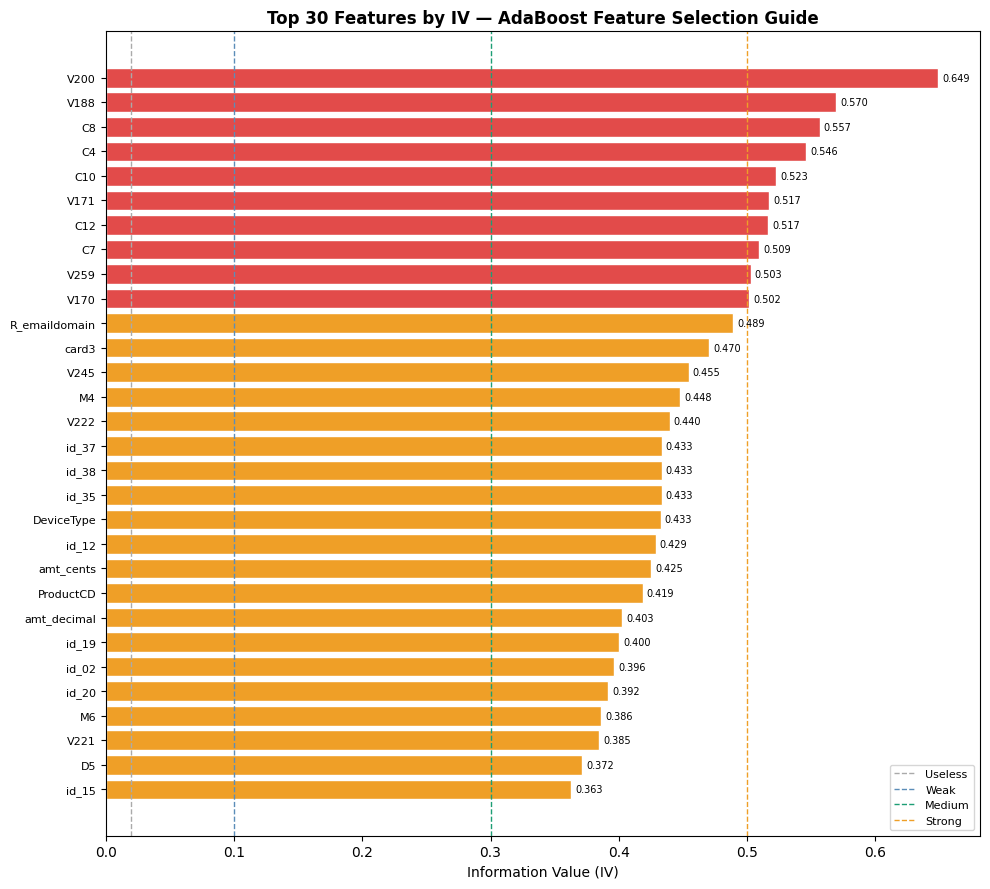

In [7]:

top30_iv = all_iv_df.head(30)

fig, ax = plt.subplots(figsize=(10, 9))

color_map = {
    "Very Strong": "#E24B4A",
    "Strong": "#EF9F27",
    "Medium": "#1D9E75",
    "Weak": "#5B8DB8",
    "Useless": "#aaaaaa"
}

iv_colors = [color_map[s] for s in top30_iv["strength"]]

ax.barh(range(len(top30_iv)), top30_iv["iv"].values,
        color=iv_colors, edgecolor="white")

ax.set_yticks(range(len(top30_iv)))
ax.set_yticklabels(top30_iv["feature"].values, fontsize=8)
ax.invert_yaxis()

for threshold, color, label in [
    (0.02, "#aaaaaa", "Useless"),
    (0.10, "#5B8DB8", "Weak"),
    (0.30, "#1D9E75", "Medium"),
    (0.50, "#EF9F27", "Strong")
]:
    ax.axvline(threshold, color=color, linestyle="--", linewidth=1, label=label)

for i, v in enumerate(top30_iv["iv"].values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=7)

ax.set_xlabel("Information Value (IV)")
ax.set_title("Top 30 Features by IV — AdaBoost Feature Selection Guide",
             fontsize=12, fontweight="bold")

ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("ada_chart5_iv_scores.png", dpi=130, bbox_inches="tight")
plt.show()



## **FEATURE SELECTION**

Fitting AdaBoost for feature importance...
Done.

=== Method A: IV-based ===
  96 features | AUC = 0.8560
=== Method B: Top 50% Importance ===
  49 features | AUC = 0.8584
=== Method C: SelectFromModel ===
  48 features | AUC = 0.8578

=== Comparison ===
              method  n      auc
          IV (≥0.02) 96 0.856049
Importance (top 50%) 49 0.858382
     SelectFromModel 48 0.857757

Best: Importance (top 50%) (49 features)


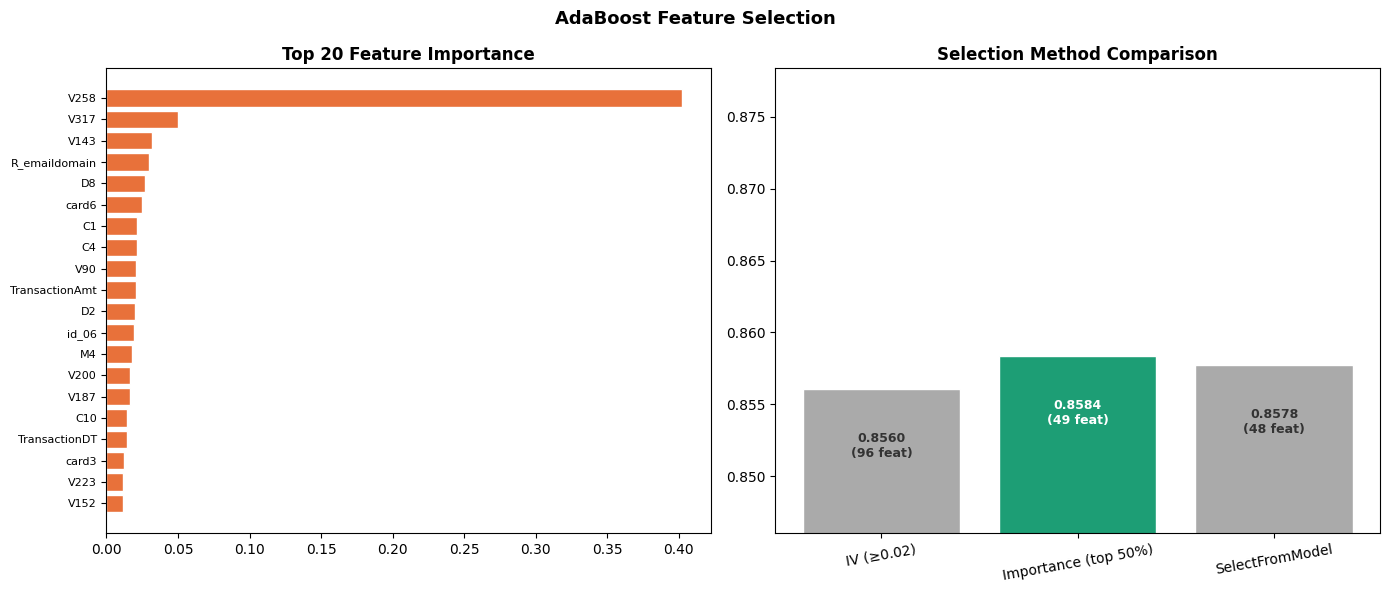


X_tr_sel : (472432, 49)
X_val_sel: (118108, 49)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import json
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name='AdaBoost_Feature_Selection'):

    feature_names = X_tr.columns.tolist()
    n_total       = len(feature_names)


    print('Fitting AdaBoost for feature importance...')
    ada_fs = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=1.0,
        algorithm='SAMME',
        random_state=42
    )
    ada_fs.fit(X_tr.values, y_train)
    print('Done.')

    importances = pd.Series(
        ada_fs.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    # Method A: IV-based 
    print('\n=== Method A: IV-based ===')
    by_iv = all_iv_df.loc[all_iv_df['iv'] >= 0.02, 'feature'].tolist()
    by_iv = [f for f in by_iv if f in X_tr.columns]
    ada_fs.fit(X_tr[by_iv].values, y_train)
    auc_iv = roc_auc_score(y_valid, ada_fs.predict_proba(X_val[by_iv].values)[:, 1])
    print(f'  {len(by_iv)} features | AUC = {auc_iv:.4f}')

    # Method B: Top 50% by importance 
    print('=== Method B: Top 50% Importance ===')
    by_imp = importances[importances > importances.quantile(0.50)].index.tolist()
    ada_fs.fit(X_tr[by_imp].values, y_train)
    auc_imp = roc_auc_score(y_valid, ada_fs.predict_proba(X_val[by_imp].values)[:, 1])
    print(f'  {len(by_imp)} features | AUC = {auc_imp:.4f}')

    # Method C: SelectFromModel (mean threshold)
    print('=== Method C: SelectFromModel ===')
    ada_fs.fit(X_tr.values, y_train)
    by_sfm = [f for f, s in zip(feature_names,
            SelectFromModel(ada_fs, threshold='mean', prefit=True).get_support()) if s]
    ada_fs.fit(X_tr[by_sfm].values, y_train)
    auc_sfm = roc_auc_score(y_valid, ada_fs.predict_proba(X_val[by_sfm].values)[:, 1])
    print(f'  {len(by_sfm)} features | AUC = {auc_sfm:.4f}')

    sel_results = [
        {'method': 'IV (≥0.02)',           'n': len(by_iv),  'auc': auc_iv,  'features': by_iv},
        {'method': 'Importance (top 50%)', 'n': len(by_imp), 'auc': auc_imp, 'features': by_imp},
        {'method': 'SelectFromModel',      'n': len(by_sfm), 'auc': auc_sfm, 'features': by_sfm},
    ]
    sel_df       = pd.DataFrame([{k: v for k, v in r.items() if k != 'features'} for r in sel_results])
    best_idx     = sel_df['auc'].idxmax()
    FINAL_FEATURES = sel_results[best_idx]['features']

    X_tr_sel  = X_tr[FINAL_FEATURES].copy()
    X_val_sel = X_val[FINAL_FEATURES].copy()

    print('\n=== Comparison ===')
    print(sel_df.to_string(index=False))
    print(f'\nBest: {sel_results[best_idx]["method"]} ({len(FINAL_FEATURES)} features)')


    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    top20 = importances.head(20)
    axes[0].barh(range(len(top20)), top20.values, color='#E8713A', edgecolor='white')
    axes[0].set_yticks(range(len(top20)))
    axes[0].set_yticklabels(top20.index, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_title('Top 20 Feature Importance', fontweight='bold')

    colors = ['#1D9E75' if i == best_idx else '#aaaaaa' for i in range(len(sel_df))]
    axes[1].bar(sel_df['method'], sel_df['auc'], color=colors, edgecolor='white')
    for i, (_, row) in enumerate(sel_df.iterrows()):
        axes[1].text(i, row['auc'] - 0.003,
                    f"{row['auc']:.4f}\n({row['n']} feat)",
                    ha='center', va='top', fontsize=9, fontweight='bold',
                    color='white' if i == best_idx else '#333333')
    axes[1].set_ylim(min(sel_df['auc']) - 0.01, max(sel_df['auc']) + 0.02)
    axes[1].set_title('Selection Method Comparison', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=10)

    plt.suptitle('AdaBoost Feature Selection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ada_chart6_feature_selection.png', dpi=130, bbox_inches='tight')
    plt.show()

    with open('ada_selected_features.json', 'w') as f:
        json.dump(FINAL_FEATURES, f)





    #   mlflow.log_param('best_method',     sel_results[best_sel_idx]['method'])
    #  mlflow.log_metric('features_total', n_total)
    #    mlflow.log_metric('features_iv',    len(by_iv))
    #    mlflow.log_metric('features_imp',   len(by_imp))
    ##    mlflow.log_metric('features_sfm',   len(by_sfm))
    #    mlflow.log_metric('features_final', len(FINAL_FEATURES))
    #    mlflow.log_metric('val_auc_iv',     auc_iv)
    #    mlflow.log_metric('val_auc_imp',    auc_imp)
    #    mlflow.log_metric('val_auc_sfm',    auc_sfm)
    #    mlflow.log_artifact('ada_chart6_feature_selection.png')
    #    mlflow.log_artifact('ada_selected_features.json')

    print(f'\nX_tr_sel : {X_tr_sel.shape}')
    print(f'X_val_sel: {X_val_sel.shape}')

## **TRAINING**

In [12]:
def run_cv_ada(X_features, y_target, model_params, n_splits=5):
    
    X_arr = X_features.values if hasattr(X_features, 'values') else X_features
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof   = np.zeros(len(y_target))
    cv_aucs, tr_aucs = [], []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y_target)):
        X_tr_f, X_v_f = X_arr[tr_idx], X_arr[val_idx]
        y_tr_f, y_v_f = y_target[tr_idx], y_target[val_idx]

        base = DecisionTreeClassifier(**model_params.get('base_params', {'max_depth': 1}))
        model = AdaBoostClassifier(
            estimator=base,
            n_estimators=model_params['n_estimators'],
            learning_rate=model_params['learning_rate'],
            algorithm=model_params.get('algorithm', 'SAMME'),
            random_state=42)
        model.fit(X_tr_f, y_tr_f)

        oof[val_idx] = model.predict_proba(X_v_f)[:, 1]
        cv_aucs.append(roc_auc_score(y_v_f,  oof[val_idx]))
        tr_aucs.append(roc_auc_score(y_tr_f, model.predict_proba(X_tr_f)[:, 1]))
        print(f'  Fold {fold+1}: Val={cv_aucs[-1]:.4f} | Train={tr_aucs[-1]:.4f} | Gap={tr_aucs[-1]-cv_aucs[-1]:.4f}')

    return cv_aucs, tr_aucs, oof

In [ ]:
from sklearn.metrics import average_precision_score
try:
    mlflow.end_run()
except Exception:
    pass
configs = [
    ('Ada_depth1_n10_lr05', 1, 10, 0.01),
    ('Ada_depth1_n100_lr1',  1, 100, 1.0),
    ('Ada_depth1_n300_lr1',  1, 300, 1.0),
    ('Ada_depth1_n500_lr05',  1, 500, 0.5),
    ('Ada_depth1_n500_lr01',  1, 500, 0.1),
    ('Ada_depth2_n300_lr1',   2, 300, 1.0),
    ('Ada_depth2_n500_lr05',  2, 500, 0.5),
    ('Ada_depth2_n300_lr01',  2, 300, 0.1),
    ('Ada_depth3_n200_lr05',  3, 200, 0.5),
    ('Ada_depth3_n1000_lr05', 3, 1000, 1.0),
    
]

grid_results = []

for name, depth, n_est, lr in configs:
    p = {'n_estimators': n_est, 'learning_rate': lr,
         'algorithm': 'SAMME', 'base_params': {'max_depth': depth}}

    with mlflow.start_run(run_name=name):
        cv, tr, oof = run_cv_ada(X_tr_sel, y_train, p)
        cv_m, tr_m, gap = np.mean(cv), np.mean(tr), np.mean(tr)-np.mean(cv)

        base_g = DecisionTreeClassifier(max_depth=depth)
        ada_g  = AdaBoostClassifier(estimator=base_g, n_estimators=n_est,
                                    learning_rate=lr, algorithm='SAMME', random_state=42)
        ada_g.fit(X_tr_sel.values, y_train)
        val_preds_g = ada_g.predict_proba(X_val_sel.values)[:, 1]
        val_auc  = roc_auc_score(y_valid, val_preds_g)
        val_prauc = average_precision_score(y_valid, val_preds_g)

        status = 'OVERFITTING' if gap > 0.05 else ('UNDERFITTING' if cv_m < 0.80 else 'OK')

        mlflow.log_param('n_estimators',  n_est)
        mlflow.log_param('learning_rate', lr)
        mlflow.log_param('base_depth',    depth)
        mlflow.log_metric('auc_cv_mean',     cv_m)
        mlflow.log_metric('auc_train_avg',   tr_m)
        mlflow.log_metric('auc_val_holdout', val_auc)
        mlflow.log_metric('prauc_val',       val_prauc)
        mlflow.log_metric('overfitting_gap', gap)
        mlflow.set_tag('status', status)

        grid_results.append({'config': name, 'cv_auc': cv_m, 'val_auc': val_auc,
                             'val_prauc': val_prauc, 'gap': gap, 'status': status})

res_df = pd.DataFrame(grid_results).sort_values('val_auc', ascending=False)



KeyError: 'val_auc'

## **FINAL MODEL PIPELINE**

In [19]:

FINAL_PARAMS = {
    'n_estimators' : 500,
    'learning_rate': 0.5,
    'algorithm'    : 'SAMME',
    'base_params'  : {'max_depth': 2}
}

with mlflow.start_run(run_name='AdaBoost_Final') as run:

    cv_aucs, tr_aucs, oof_preds = run_cv_ada(X_tr_sel, y_train, FINAL_PARAMS, n_splits=5)

    oof_auc  = roc_auc_score(y_train, oof_preds)
    oof_prauc = average_precision_score(y_train, oof_preds)
    cv_m     = np.mean(cv_aucs)
    tr_m     = np.mean(tr_aucs)

    base_final = DecisionTreeClassifier(**FINAL_PARAMS['base_params'])
    final_ada  = AdaBoostClassifier(
        estimator=base_final,
        n_estimators=FINAL_PARAMS['n_estimators'],
        learning_rate=FINAL_PARAMS['learning_rate'],
        algorithm=FINAL_PARAMS['algorithm'],
        random_state=42)
    final_ada.fit(X_tr_sel.values, y_train)

    val_preds = final_ada.predict_proba(X_val_sel.values)[:, 1]
    val_auc   = roc_auc_score(y_valid, val_preds)
    val_prauc = average_precision_score(y_valid, val_preds)

    class AdaPreprocessor(BaseEstimator, TransformerMixin):
        def __init__(self):
            self.high_nan_cols_   = high_nan_cols
            self.missing_cols_    = missing_cols
            self.label_enc_clean_ = label_enc_clean
            self.cat_cols_cur_    = cat_cols_cur
            self.imputer_         = imputer
            self.col_names_       = col_names
            self.cap_bounds_      = cap_bounds
            self.high_corr_       = high_corr
            self.low_var_cols_    = low_var_cols
            self.final_features_  = FINAL_FEATURES

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

            df.drop(columns=[c for c in self.high_nan_cols_ if c in df.columns], inplace=True)

            for col in self.missing_cols_:
                df[col + '_was_nan'] = df[col].isnull().astype(np.int8) if col in df.columns else 0

            for col in self.cat_cols_cur_:
                if col in df.columns:
                    le    = self.label_enc_clean_.get(col)
                    known = set(le.classes_) if le else set()
                    df[col] = df[col].astype(str).fillna('missing').map(
                        lambda v: le.transform([v])[0] if le and v in known else 0)

            for c in self.col_names_:
                if c not in df.columns:
                    df[c] = 0

            df = pd.DataFrame(
                self.imputer_.transform(df[self.col_names_]),
                columns=self.col_names_)

            for col, (lo, hi) in self.cap_bounds_.items():
                if col in df.columns:
                    df[col] = df[col].clip(lo, hi)

            df.drop(columns=[c for c in self.high_corr_ + self.low_var_cols_ if c in df.columns], inplace=True)

            if 'TransactionDT' in df.columns:
                df['hour_of_day']  = (df['TransactionDT'] // 3600) % 24
                df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
                df['day_of_month'] = (df['TransactionDT'] // 86400) % 30
                df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
                df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)

            if 'TransactionAmt' in df.columns:
                df['amt_log']      = np.log1p(df['TransactionAmt'])
                df['amt_decimal']  = df['TransactionAmt'] % 1
                df['amt_is_round'] = (df['TransactionAmt'] % 1 < 0.01).astype(int)
                df['amt_cents']    = (df['TransactionAmt'] * 100).astype(int) % 100

            for col in self.final_features_:
                if col not in df.columns:
                    df[col] = 0

            return df[self.final_features_].values

    ada_pipeline = Pipeline(steps=[
        ('preprocessor', AdaPreprocessor()),
        ('classifier',   AdaBoostClassifier(
            estimator=DecisionTreeClassifier(**FINAL_PARAMS['base_params']),
            n_estimators=FINAL_PARAMS['n_estimators'],
            learning_rate=FINAL_PARAMS['learning_rate'],
            algorithm=FINAL_PARAMS['algorithm'],
            random_state=42))
    ])

    ada_pipeline.fit(X_train, y_train)

    pipe_val_preds = ada_pipeline.predict_proba(X_valid)[:, 1]
    pipe_val_auc   = roc_auc_score(y_valid, pipe_val_preds)

    mlflow.sklearn.log_model(
        ada_pipeline,
        artifact_path='ada_pipeline')

  Fold 1: Val=0.8802 | Train=0.8831 | Gap=0.0030
  Fold 2: Val=0.8754 | Train=0.8839 | Gap=0.0085
  Fold 3: Val=0.8824 | Train=0.8823 | Gap=-0.0002
  Fold 4: Val=0.8761 | Train=0.8845 | Gap=0.0084
  Fold 5: Val=0.8823 | Train=0.8820 | Gap=-0.0003
🏃 View run AdaBoost_Final at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/3/runs/2e05c894000445b98f3a643778306156
🧪 View experiment at: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow/#/experiments/3


NameError: name 'label_enc_clean' is not defined